# **HDF5 Chunked Consolidation**
---

**Purpose:** Consolidate 500 episode files from S3 into multiple chunk files using minimal local disk.

**Why Chunks?** Writing HDF5 directly to S3 fails because:
- HDF5 requires `seek()` support in write mode
- S3 (via s3fs) only supports `seek()` in read mode
- HDF5 assumes random access (POSIX), S3 is sequential write-only

**Solution:** Chunked approach:
1. ✅ Process episodes in chunks (50 episodes = ~7-8GB)
2. ✅ Write each chunk locally
3. ✅ Upload chunk to S3
4. ✅ Delete local chunk (free disk)
5. ✅ Repeat for all episodes

**Result:**
- Local disk: Only ~8GB peak (one chunk at a time)
- S3: Multiple chunks (chunk_0000.h5, chunk_0001.h5, ...)
- Training: Use `ChunkedHDF5Dataset` to read from all chunks

---

## **Setup**
---

In [1]:
from jepacartpole.data_prep import (
    consolidate_episodes_in_chunks,
    get_chunk_info,
    create_chunked_dataset
)

print("✓ Imports successful")

✓ Imports successful


In [2]:
# Configuration
S3_BUCKET = 'tcc-jepa-cartpole'
S3_SOURCE_PREFIX = 'tmp/raw_data'           # Source episode files
S3_OUTPUT_PREFIX = 'chunks/dataset'         # Output chunks

CHUNK_SIZE = 50  # Episodes per chunk (~7-8GB each)
MAX_STEPS = 500  # Steps per episode

print("Configuration:")
print(f"  Source: s3://{S3_BUCKET}/{S3_SOURCE_PREFIX}")
print(f"  Output: s3://{S3_BUCKET}/{S3_OUTPUT_PREFIX}/chunk_*.h5")
print(f"  Chunk size: {CHUNK_SIZE} episodes (~7-8GB per chunk)")
print(f"  Max steps: {MAX_STEPS}")
print()
print("For 500 episodes:")
print(f"  Number of chunks: {500 // CHUNK_SIZE}")
print(f"  Local disk usage: ~8GB peak (one chunk at a time)")
print(f"  Total S3 storage: ~150GB (all chunks combined)")

Configuration:
  Source: s3://tcc-jepa-cartpole/tmp/raw_data
  Output: s3://tcc-jepa-cartpole/chunks/dataset/chunk_*.h5
  Chunk size: 50 episodes (~7-8GB per chunk)
  Max steps: 500

For 500 episodes:
  Number of chunks: 10
  Local disk usage: ~8GB peak (one chunk at a time)
  Total S3 storage: ~150GB (all chunks combined)


## **Run Chunked Consolidation**
---

This will:
1. **Check if chunks already exist** in S3
2. If they exist → Skip consolidation ⏭️
3. If not → Process and consolidate:
   - Process 50 episodes → Write locally (~8GB)
   - Upload to S3 → Delete locally
   - Repeat 10 times (for 500 total episodes)

**Time:** 
- If skipped: <1 second
- If consolidating: ~30-40 minutes for 500 episodes

**Note:** To force re-consolidation, set `skip_if_exists=False`

In [3]:
%%time

result = consolidate_episodes_in_chunks(
    s3_bucket=S3_BUCKET,
    s3_prefix=S3_SOURCE_PREFIX,
    s3_output_prefix=S3_OUTPUT_PREFIX,
    chunk_size=CHUNK_SIZE,
    max_steps=MAX_STEPS,
    local_temp_dir='/tmp/consolidation',
    verify_chunks=True,
    delete_local_after_upload=True,
    skip_if_exists=True,  # Skip if chunks already exist
    verbose=True
)

print("\n" + "=" * 80)
print("CONSOLIDATION RESULT")
print("=" * 80)

if result.get('skipped', False):
    print("✅ Consolidation SKIPPED - chunks already exist in S3")
else:
    print("✅ Consolidation COMPLETED - new chunks created")

print(f"  Chunks: {result['num_chunks']}")
print(f"  Total episodes: {result['total_episodes']}")
print(f"  S3 location: {result['s3_location']}")
print("=" * 80)

HDF5 CHUNKED CONSOLIDATION
Source: s3://tcc-jepa-cartpole/tmp/raw_data
Destination: s3://tcc-jepa-cartpole/chunks/dataset/chunk_*.h5
Chunk size: 50 episodes
Local temp: /tmp/consolidation

🔍 Checking if chunks already exist in S3...
✓ Found 10 existing chunks in S3

⏭️  SKIPPING CONSOLIDATION - CHUNKS ALREADY EXIST
Location: s3://tcc-jepa-cartpole/chunks/dataset/
Existing chunks: 10

Total episodes in existing chunks: 500

To force re-consolidation, set skip_if_exists=False

CONSOLIDATION RESULT
✅ Consolidation SKIPPED - chunks already exist in S3
  Chunks: 10
  Total episodes: 500
  S3 location: s3://tcc-jepa-cartpole/chunks/dataset/
CPU times: user 937 ms, sys: 726 ms, total: 1.66 s
Wall time: 9.88 s


## **Verify Chunks**
---

In [4]:
# Get chunk information
info = get_chunk_info(S3_BUCKET, S3_OUTPUT_PREFIX)

print("Chunks Information:")
print(f"  Location: {info['s3_location']}")
print(f"  Number of chunks: {info['num_chunks']}")
print(f"  Total episodes: {info['total_episodes']}")
print(f"  Episodes per chunk: {info['episodes_per_chunk']}")
print(f"  Steps per episode: {info['max_steps']}")
print(f"  Image shape: {info['image_shape']}")
print()
print(f"Total frames: {info['total_episodes'] * info['max_steps']:,}")

Chunks Information:
  Location: s3://tcc-jepa-cartpole/chunks/dataset/
  Number of chunks: 10
  Total episodes: 500
  Episodes per chunk: 50
  Steps per episode: 500
  Image shape: (400, 600, 3)

Total frames: 250,000


## **Test Dataset Access**
---

Test reading data from chunks using the `ChunkedHDF5Dataset`:

In [5]:
# Create dataset
dataset = create_chunked_dataset(
    s3_bucket=S3_BUCKET,
    s3_chunk_prefix=S3_OUTPUT_PREFIX,
    use_s3=True
)

print(f"Dataset created successfully!")
print(f"  Total frames: {len(dataset):,}")
print(f"  Total episodes: {dataset.total_episodes}")
print(f"  Steps per episode: {dataset.max_steps}")

Dataset created successfully!
  Total frames: 250,000
  Total episodes: 500
  Steps per episode: 500


In [6]:
# Get a single frame
image, action, reward, done = dataset[0]

print("Sample frame (index 0):")
print(f"  Image shape: {image.shape}")
print(f"  Image dtype: {image.dtype}")
print(f"  Image range: [{image.min():.3f}, {image.max():.3f}]")
print(f"  Action: {action:.1f}")
print(f"  Reward: {reward:.1f}")
print(f"  Done: {done}")

Sample frame (index 0):
  Image shape: torch.Size([3, 400, 600])
  Image dtype: torch.float32
  Image range: [0.000, 1.000]
  Action: 1.0
  Reward: 1.0
  Done: False


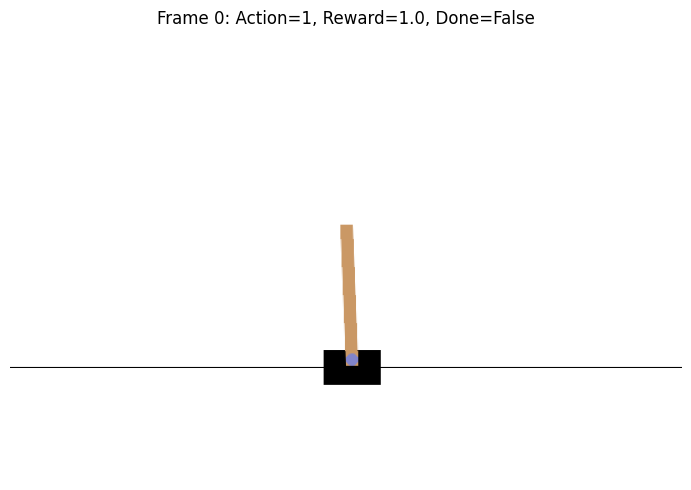

✓ Successfully read and displayed data from chunks!


In [7]:
import matplotlib.pyplot as plt

# Visualize sample frame
image_np = image.permute(1, 2, 0).numpy()  # CHW → HWC

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(image_np)
ax.set_title(f'Frame 0: Action={action:.0f}, Reward={reward:.1f}, Done={done}')
ax.axis('off')
plt.tight_layout()
plt.show()

print("✓ Successfully read and displayed data from chunks!")

In [8]:
# Get a complete episode
episode = dataset.get_episode(0)

print("Complete episode 0:")
print(f"  Images shape: {episode['images'].shape}")  # (steps, C, H, W)
print(f"  Actions shape: {episode['actions'].shape}")  # (steps,)
print(f"  Rewards shape: {episode['rewards'].shape}")  # (steps,)
print(f"  Dones shape: {episode['dones'].shape}")    # (steps,)
print()
print(f"  Total reward: {episode['rewards'].sum():.1f}")
print(f"  Episode length: {episode['dones'].sum().item()} resets")

Complete episode 0:
  Images shape: torch.Size([500, 3, 400, 600])
  Actions shape: torch.Size([500])
  Rewards shape: torch.Size([500])
  Dones shape: torch.Size([500])

  Total reward: 500.0
  Episode length: 49 resets
